In [1]:
from style_encoder_train_cyrillic import HKRDataset_style
from torchvision import transforms

/home/oles/DiffusionPen/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


num_tokens 1


In [2]:
from style_encoder_train_cyrillic import HKRDataset_style, transforms
train_dataset = HKRDataset_style('hkr-dataset', 'train', 'word', (64, 256),
                                 transforms=transforms.Compose([transforms.ToTensor()]))
val_dataset = HKRDataset_style('hkr-dataset', 'val', 'word', (64, 256),
                                 transforms=transforms.Compose([transforms.ToTensor()]))
len(train_dataset), len(val_dataset), train_dataset.wclasses


save_file ./IAM_dataset_PIL_style/train_word_HKR_v2.pt
Number of writers 268
save_file ./IAM_dataset_PIL_style/val_word_HKR_v2.pt
Number of writers 268


(64943, 64943, 268)

Confirmed correct numbers. Now checking triplets visually:

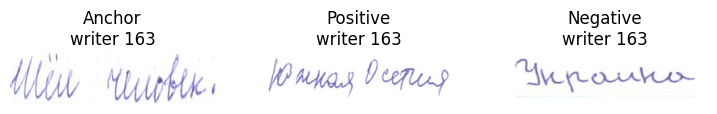

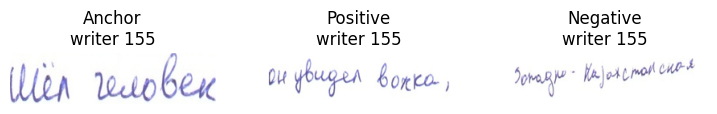

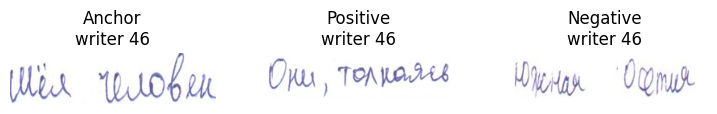

In [4]:
import matplotlib.pyplot as plt

def show_triplet(ds, idx):
    anchor, _, _, wid, pos, neg, _, _, paths, *_ = ds[idx]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, img, title in zip(axes,
                              [anchor.permute(1,2,0), pos.permute(1,2,0), neg.permute(1,2,0)],
                              ['Anchor', 'Positive', 'Negative']):
        ax.imshow(img.numpy(), cmap='gray')
        ax.set_title(f'{title}\nwriter {wid}')
        ax.axis('off')
    plt.show()

show_triplet(train_dataset, 0)
show_triplet(train_dataset, 1)
show_triplet(train_dataset, 2)



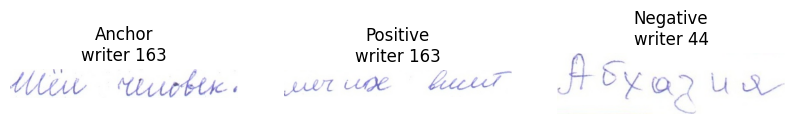

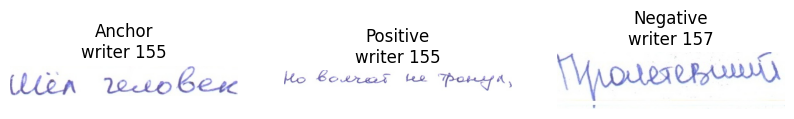

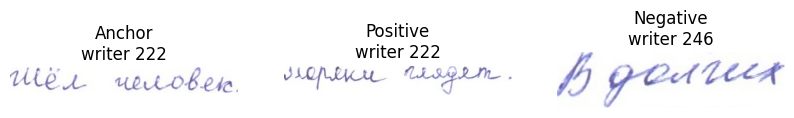

In [6]:
import random
import matplotlib.pyplot as plt
import torch

def get_triplet_with_ids(ds, idx):
    anchor = ds.data[idx]
    anchor_img, anchor_text, anchor_wid, anchor_path = anchor

    positives = [p for p in ds.data if p[2] == anchor_wid and len(p[1]) > 3 and p is not anchor]
    if not positives:
        positives = [p for p in ds.data if p[2] == anchor_wid]
    pos_sample = random.choice(positives)
    pos_img, _, pos_wid, _ = pos_sample

    negatives = [n for n in ds.data if n[2] != anchor_wid and len(n[1]) > 3]
    if negatives:
        neg_sample = random.choice(negatives)
    else:
        fallback = [n for n in ds.data if n is not anchor]
        neg_sample = random.choice(fallback)
    neg_img, _, neg_wid, _ = neg_sample

    return (anchor_img, anchor_wid), (pos_img, pos_wid), (neg_img, neg_wid)

import numpy as np
import torch
import matplotlib.pyplot as plt

def as_array(img):
    if isinstance(img, torch.Tensor):
        return img.permute(1, 2, 0).numpy()
    return np.array(img)

def plot_triplet(ds, idx):
    (anchor_img, anchor_wid), (pos_img, pos_wid), (neg_img, neg_wid) = get_triplet_with_ids(ds, idx)
    imgs = [anchor_img, pos_img, neg_img]
    labels = [f'Anchor\nwriter {anchor_wid}',
              f'Positive\nwriter {pos_wid}',
              f'Negative\nwriter {neg_wid}']

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, img, lab in zip(axes, imgs, labels):
        arr = as_array(img)
        ax.imshow(arr, cmap='gray')
        ax.set_title(lab)
        ax.axis('off')
    plt.show()


plot_triplet(train_dataset, 0)
plot_triplet(train_dataset, 1)
plot_triplet(train_dataset, 3)


Now I compute distances

In [12]:
import torch, numpy as np
from torch.utils.data import DataLoader
from style_encoder_train_cyrillic import ImageEncoder

ckpt_path = 'style_models/triplet_hkr_mobilenetv2_100.pth'
model = ImageEncoder('mobilenetv2_100', num_classes=0, pretrained=False, trainable=False)
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
model.eval()

loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
all_embeds, all_wids = [], []

with torch.no_grad():
    for images, _, _, wids, *_ in loader:
        emb = model(images).view(images.size(0), -1)
        all_embeds.append(emb)
        all_wids.append(wids)
        counts = np.bincount(torch.cat(all_wids).numpy())
        if (counts > 1).any(): # stop once we have at least one repeated writer
            break

embeds = torch.cat(all_embeds, dim=0)
wids = torch.cat(all_wids).numpy()

pairwise = torch.cdist(embeds, embeds).numpy()
same_mask = (wids[:, None] == wids[None, :]) & ~np.eye(len(wids), dtype=bool)
diff_mask = wids[:, None] != wids[None, :]

intra = pairwise[same_mask]
inter = pairwise[diff_mask]

print('Intra-writer mean distance:', intra.mean())
print('Inter-writer mean distance:', inter.mean())

Intra-writer mean distance: 2.4634516
Inter-writer mean distance: 6.7607536


In [15]:
torch.cuda.is_available()

True

In [16]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from style_encoder_train_cyrillic import ImageEncoder

def top_k_neighbors(dataset, anchor_index=0, k=5,
                    ckpt_path='style_models/triplet_hkr_mobilenetv2_100.pth',
                    device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = ImageEncoder('mobilenetv2_100', num_classes=0,
                         pretrained=False, trainable=False).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    loader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=4)

    embeds = []
    writers = []
    with torch.no_grad():
        for imgs, _, _, wids, *_ in loader:
            imgs = imgs.to(device)
            emb = model(imgs).view(imgs.size(0), -1).cpu()
            embeds.append(emb)
            writers.append(wids)
    embeds = torch.cat(embeds)
    writers = torch.cat(writers).numpy()

    anchor_emb = embeds[anchor_index].unsqueeze(0)
    dists = torch.cdist(anchor_emb, embeds).squeeze(0).numpy()

    idx_sorted = np.argsort(dists)
    top_idx = [idx for idx in idx_sorted if idx != anchor_index][:k]

    print(f'Anchor idx {anchor_index}, writer {writers[anchor_index]}')
    for rank, idx in enumerate(top_idx, 1):
        print(f'#{rank}: idx {idx}, writer {writers[idx]}, distance {dists[idx]:.3f}')

    return top_idx, dists[top_idx]


top_k_neighbors(val_dataset, anchor_index=42, k=5)

Anchor idx 42, writer 46
#1: idx 33560, writer 572, distance 1.249
#2: idx 3788, writer 46, distance 1.279
#3: idx 58120, writer 1489, distance 1.285
#4: idx 35988, writer 572, distance 1.338
#5: idx 33250, writer 572, distance 1.359


([np.int64(33560),
  np.int64(3788),
  np.int64(58120),
  np.int64(35988),
  np.int64(33250)],
 array([1.2493162, 1.2794385, 1.2846752, 1.3375127, 1.3585216],
       dtype=float32))

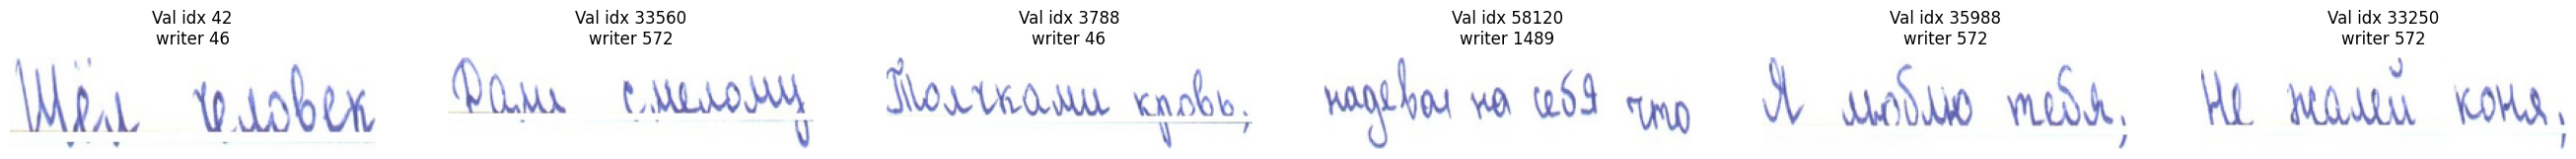

In [21]:
import matplotlib.pyplot as plt

def plot_top_neighbors(dataset, anchor_idx, neighbors, title_prefix='Val'):
    idx_list = [anchor_idx] + neighbors
    cols = len(idx_list)
    fig, axes = plt.subplots(1, cols, figsize=(4.5 * cols, 4))
    for ax, idx in zip(axes, idx_list):
        img, _, _, wid, *_ = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{title_prefix} idx {idx}\nwriter {wid}', fontsize=12, pad=10)
        ax.axis('off')
    plt.subplots_adjust(wspace=0.2, left=0.02, right=0.98, top=0.85, bottom=0.05)
    plt.show()

anchor_idx = 42
neighbor_idx = [33560, 3788, 58120, 35988, 33250]
plot_top_neighbors(val_dataset, anchor_idx, neighbor_idx)


In [ ]:
from collections import defaultdict
from pathlib import Path
import torch
from style_encoder_train_cyrillic import HKRDataset_style, transforms

cluster_map_path = Path("writer_cluster_map_embedded.json").resolve()

dataset = HKRDataset_style(
    basefolder="hkr-dataset",
    subset="all",
    segmentation_level="word",
    fixed_size=(64, 256),
    transforms=transforms.Compose([transforms.ToTensor()]),
    cluster_map_file=str(cluster_map_path),   # ensure the clustered IDs are loaded
)

forms_to_clusters = defaultdict(set)

for sample_id, record in dataset._records_by_sample.items():
    form_id = sample_id.rsplit("_", 1)[0]          # e.g. "0_23" for "0_23_17"
    cluster_idx = dataset.writer_to_index[record.writer_id]
    forms_to_clusters[form_id].add(cluster_idx)

split_forms = {form: ids for form, ids in forms_to_clusters.items() if len(ids) > 1}

print(f"{len(split_forms)} forms contain multiple clustered writer IDs.")
for form in list(split_forms)[:5]:
    print(form, sorted(split_forms[form]))


save_file ./IAM_dataset_PIL_style/all_word_HKR_v2.pt
Number of writers 14
0 forms contain multiple clustered writer IDs.
